# 16. Live Tutorial 1: PCA & Factor Analysis — Finding Structure in a Cathode Database

A materials-informatics team has characterised 150 NMC-type Li-ion cathode
materials, recording 10 measurements per sample — particle morphology,
electrochemical performance, and cycling stability. No single column tells
the whole story, and plotting 10 variables pairwise means
$\binom{10}{2}=45$ scatter plots. This session uses that one dataset to
learn **PCA** (compress correlated variables into a handful of
interpretable axes) and **Factor Analysis** (go one step further and
recover the *hidden physical drivers* behind the correlations) — the two
methods theory.md pairs together because they answer closely related
questions with genuinely different assumptions.

We build PCA from scratch in raw NumPy before ever calling `sklearn` — the
goal is that by the end, "principal component" means a specific, concrete
linear-algebra object you built with your own hands, not a black-box
output.

**Session plan**
1. The problem: 10 correlated columns, one dataset
2. PCA from scratch (NumPy only) — and proof it matches `sklearn`
3. Applying PCA: scree, scores, loadings, biplot
4. Hotelling's T²: a genuine multivariate outlier/control-chart tool
5. From PCA to Factor Analysis: what changes, and why
6. How many factors? Parallel analysis
7. Fitting and rotating the factor model
8. PCA vs. FA, side by side
9. *Going further*: factor scores as compressed predictors

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='ticks', palette='colorblind')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
rng = np.random.default_rng(42)

## 16.1 The Dataset: 150 Cathode Materials, 10 Variables

Three physically distinct aspects of a cathode material drive these ten
measurements, though the dataset itself does not label them — finding
that structure *is* the exercise:

- **Particle morphology**: how big the particles are, how much surface
  area they expose, how densely they pack.
- **Electrochemical performance**: how much charge the material stores and
  how fast it can deliver it.
- **Cycling stability**: how well performance holds up over repeated use.

One deliberate, real piece of materials chemistry is built into this data:
**nickel content** in NMC cathodes drives capacity *up* but cycling
stability *down* — the central Ni-Mn-Co trade-off that motivates most
cathode formulation work. Watch for it to reappear in the loadings.

In [2]:
n = 150
F_true = rng.normal(0, 1, size=(n, 3))     # 3 hidden factors: Morphology, Performance, Stability

# variable: (loading on Morphology, Performance, Stability)
loadings_true = {
    'particle_size_D50_um':          (0.85,  0.00,  0.00),
    'BET_surface_area_m2g':          (-0.80, 0.00,  0.00),
    'tap_density_gcm3':              (0.70,  0.00,  0.00),
    'first_cycle_capacity_mAhg':     (0.00,  0.85,  0.00),
    'coulombic_efficiency_pct':      (0.00,  0.60,  0.20),
    'rate_capability_pct':           (-0.30, 0.70,  0.00),
    'Ni_content_pct':                (0.00,  0.75, -0.40),
    'capacity_retention_100cyc_pct': (0.00,  0.00,  0.85),
    'impedance_growth_pct':          (0.00,  0.00, -0.75),
    'lattice_strain_pct':            (0.00,  0.00, -0.65),
}
# realistic (mean, std) in natural units for each variable
units = {
    'particle_size_D50_um':          (8.0, 2.5),
    'BET_surface_area_m2g':          (0.6, 0.15),
    'tap_density_gcm3':              (2.3, 0.30),
    'first_cycle_capacity_mAhg':     (175, 15),
    'coulombic_efficiency_pct':      (88, 3),
    'rate_capability_pct':           (80, 8),
    'Ni_content_pct':                (65, 12),
    'capacity_retention_100cyc_pct': (90, 5),
    'impedance_growth_pct':          (25, 10),
    'lattice_strain_pct':            (0.35, 0.10),
}

data = {}
for var, (l1, l2, l3) in loadings_true.items():
    unique_var = max(1e-6, 1 - (l1**2 + l2**2 + l3**2))
    z = l1*F_true[:, 0] + l2*F_true[:, 1] + l3*F_true[:, 2] + rng.normal(0, np.sqrt(unique_var), n)
    mean, sd = units[var]
    data[var] = mean + sd * z

df_cathode = pd.DataFrame(data)
df_cathode.insert(0, 'sample_id', [f'NMC-{i+1:03d}' for i in range(n)])
print(df_cathode.round(2).head())
print(f'\n{df_cathode.shape[0]} samples, {df_cathode.shape[1]-1} variables')

  sample_id  particle_size_D50_um  BET_surface_area_m2g  tap_density_gcm3  \
0   NMC-001                  8.47                  0.61              2.37   
1   NMC-002                 10.46                  0.44              2.43   
2   NMC-003                 10.84                  0.70              2.11   
3   NMC-004                  8.92                  0.65              2.56   
4   NMC-005                  8.23                  0.53              2.70   

   first_cycle_capacity_mAhg  coulombic_efficiency_pct  rate_capability_pct  \
0                     164.82                     83.69                66.59   
1                     150.93                     83.23                64.30   
2                     169.80                     87.68                80.10   
3                     198.76                     95.73                86.44   
4                     184.46                     87.11                82.78   

   Ni_content_pct  capacity_retention_100cyc_pct  impedance_gr

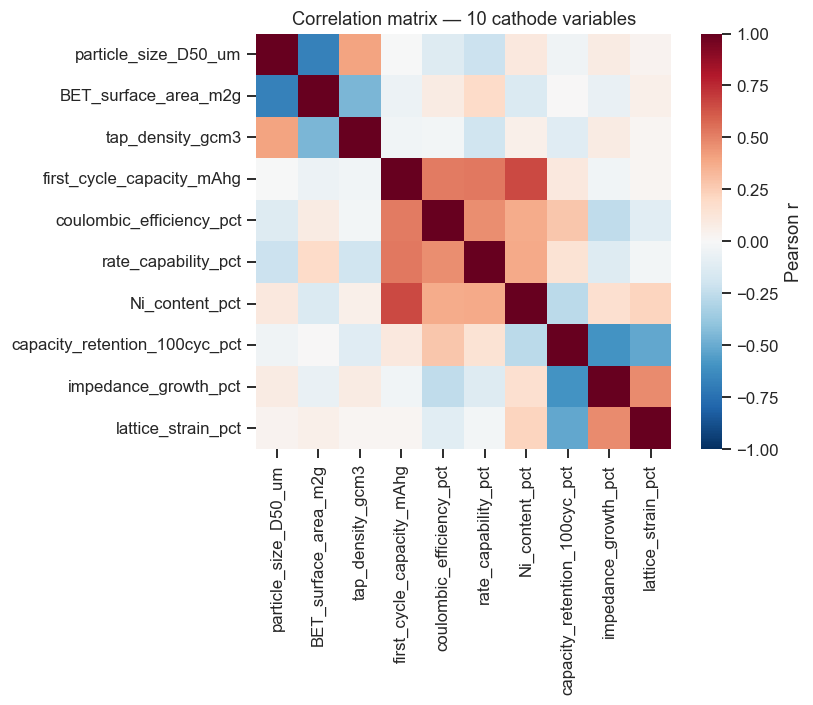

Three visually distinct correlated blocks are already visible here —
that block structure is exactly what PCA and FA make numerically precise.


In [3]:
feature_cols = [c for c in df_cathode.columns if c != 'sample_id']
corr = df_cathode[feature_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, cmap='RdBu_r', vmin=-1, vmax=1, center=0, square=True,
            annot=False, ax=ax, cbar_kws={'label': 'Pearson r'})
ax.set_title('Correlation matrix — 10 cathode variables')
plt.tight_layout()
plt.show()
print('Three visually distinct correlated blocks are already visible here —')
print('that block structure is exactly what PCA and FA make numerically precise.')

## 16.2 PCA From Scratch

theory.md describes PCA's workflow as *standardise → eigendecompose the
covariance matrix → sort by eigenvalue → project*. Every one of those
words is a single line of NumPy. `np.linalg.eigh` is the same function
Part I, Notebook 2 used to find a crystal's principal stiffness
directions — PCA is that identical idea (find the directions along which a
symmetric matrix "acts like simple multiplication"), just applied to a
*covariance* matrix instead of a stiffness tensor.

In [4]:
def pca_from_scratch(X):
    """Standardize, eigendecompose the covariance matrix, return scores,
    loadings, and the fraction of variance explained by each component."""
    # 1. Standardize: mean 0, std 1 per column (so no single variable's
    #    units -- e.g. surface area in m^2/g vs capacity in mAh/g -- dominates)
    X_mean, X_std = X.mean(axis=0), X.std(axis=0, ddof=1)
    X_scaled = (X - X_mean) / X_std

    # 2. Covariance matrix of the standardized data (= correlation matrix)
    cov = np.cov(X_scaled, rowvar=False)

    # 3. Eigendecomposition -- eigh is for symmetric matrices (covariance always is)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    # eigh returns eigenvalues ASCENDING -- PCA wants them descending
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    # 4. Project the standardized data onto the eigenvectors -> scores
    scores = X_scaled @ eigenvectors
    explained_variance_ratio = eigenvalues / eigenvalues.sum()

    return scores, eigenvectors, explained_variance_ratio


X = df_cathode[feature_cols].values
scores_manual, loadings_manual, evr_manual = pca_from_scratch(X)
print('Explained variance ratio (manual PCA):')
print(evr_manual.round(3))

Explained variance ratio (manual PCA):
[0.262 0.228 0.195 0.069 0.056 0.05  0.046 0.039 0.031 0.022]


In [5]:
# ── Verify against sklearn ─────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_scaled_sklearn = StandardScaler().fit_transform(X)
pca_sklearn = PCA()
scores_sklearn = pca_sklearn.fit_transform(X_scaled_sklearn)

print('Explained variance ratio (sklearn):')
print(pca_sklearn.explained_variance_ratio_.round(3))

# Eigenvectors can point in either direction (+v and -v are equally valid);
# compare absolute loadings, and scores up to an overall sign flip per component
signs = np.sign(np.sum(loadings_manual * pca_sklearn.components_.T, axis=0))
loadings_aligned = loadings_manual * signs
print('\nMax abs. difference in loadings (after sign alignment):',
      np.abs(loadings_aligned - pca_sklearn.components_.T).max().round(8))

Explained variance ratio (sklearn):
[0.262 0.228 0.195 0.069 0.056 0.05  0.046 0.039 0.031 0.022]

Max abs. difference in loadings (after sign alignment): 0.0


**Checkpoint**: the explained-variance ratios match to rounding, and the
loadings match once sign ambiguity is resolved (an eigenvector $v$ and
$-v$ describe the exact same axis — a well-known, harmless PCA quirk, not
a bug). From here on we use `sklearn`'s implementation, exactly as
Notebook 12 (`02_pca.ipynb`) did — but you now know precisely what it is
computing.

## 16.3 Applying PCA: Scree, Scores, Loadings, Biplot

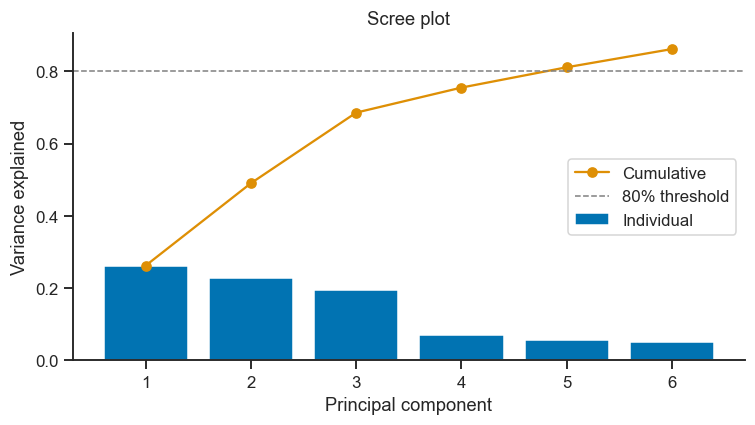

PC1+PC2+PC3 explain 68.6% of total variance
-- consistent with the data having been built from exactly 3 hidden factors.


In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
n_show = 6
ax.bar(range(1, n_show+1), pca_sklearn.explained_variance_ratio_[:n_show],
       color=sns.color_palette('colorblind')[0], label='Individual')
ax.plot(range(1, n_show+1), np.cumsum(pca_sklearn.explained_variance_ratio_[:n_show]),
        'o-', color=sns.color_palette('colorblind')[1], label='Cumulative')
ax.axhline(0.80, color='gray', ls='--', lw=1, label='80% threshold')
ax.set_xlabel('Principal component'); ax.set_ylabel('Variance explained')
ax.set_title('Scree plot')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

print(f'PC1+PC2+PC3 explain {np.cumsum(pca_sklearn.explained_variance_ratio_[:3])[-1]:.1%} of total variance')
print('-- consistent with the data having been built from exactly 3 hidden factors.')

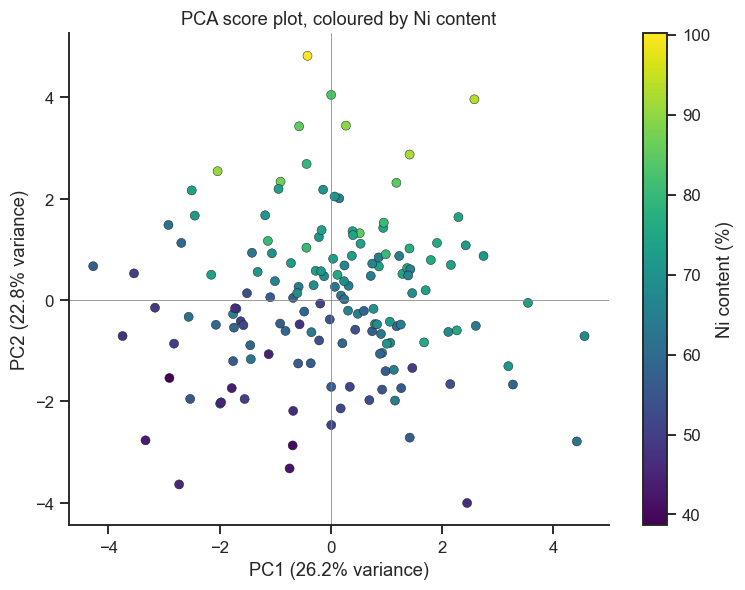

In [7]:
df_scores = pd.DataFrame(scores_sklearn[:, :3], columns=['PC1', 'PC2', 'PC3'])
df_scores['Ni_content_pct'] = df_cathode['Ni_content_pct'].values

fig, ax = plt.subplots(figsize=(7, 5.5))
sc = ax.scatter(df_scores['PC1'], df_scores['PC2'], c=df_scores['Ni_content_pct'],
                 cmap='viridis', s=35, edgecolor='k', linewidth=0.3)
ax.set_xlabel(f'PC1 ({pca_sklearn.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca_sklearn.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('PCA score plot, coloured by Ni content')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
plt.colorbar(sc, label='Ni content (%)')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

                                PC1   PC2
impedance_growth_pct          -0.30  0.34
particle_size_D50_um          -0.26  0.22
tap_density_gcm3              -0.23  0.19
lattice_strain_pct            -0.19  0.35
BET_surface_area_m2g           0.22 -0.23
Ni_content_pct                 0.22  0.53
capacity_retention_100cyc_pct  0.30 -0.36
first_cycle_capacity_mAhg      0.40  0.39
coulombic_efficiency_pct       0.45  0.16
rate_capability_pct            0.45  0.19


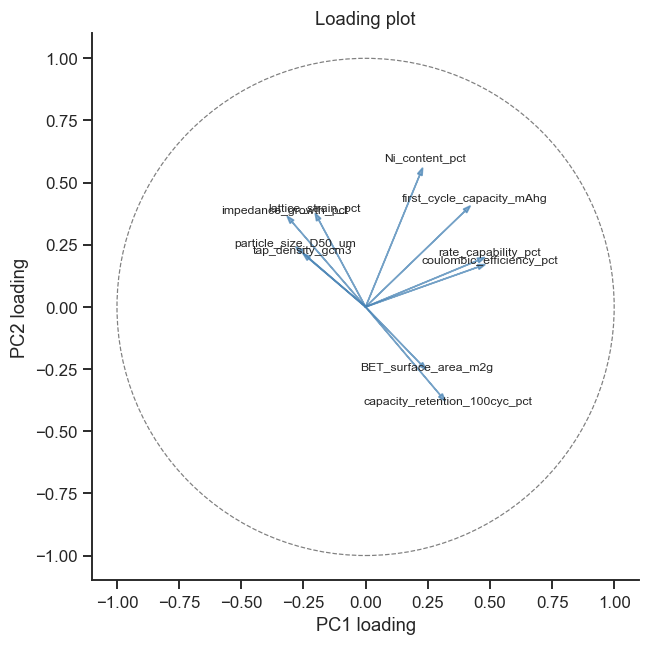

In [8]:
loadings_df = pd.DataFrame(pca_sklearn.components_[:2].T, index=feature_cols,
                            columns=['PC1', 'PC2'])
print(loadings_df.round(2).sort_values('PC1'))

fig, ax = plt.subplots(figsize=(7, 6))
for var in feature_cols:
    x, y = loadings_df.loc[var, 'PC1'], loadings_df.loc[var, 'PC2']
    ax.arrow(0, 0, x, y, head_width=0.02, color='steelblue', alpha=0.7)
    ax.text(x*1.1, y*1.1, var, fontsize=8, ha='center')
circle = plt.Circle((0, 0), 1, fill=False, color='gray', ls='--', lw=0.8)
ax.add_patch(circle)
ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
ax.set_xlabel('PC1 loading'); ax.set_ylabel('PC2 loading')
ax.set_aspect('equal')
ax.set_title('Loading plot')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

**Checkpoint / Exercise A**: Read the loading plot. Which variables point
in nearly the same direction as `Ni_content_pct`, and which point roughly
*opposite* it? Do those groupings match the "Ni raises capacity, lowers
stability" trade-off described in Section 16.1? Write one sentence naming
what PC1 physically represents in this dataset, based only on which
variables have large loadings on it.

## 16.4 Hotelling's T²: A Genuine Multivariate Outlier Tool

A univariate outlier check (Notebook 11, `bootstrap_ci`; Notebook 8's
Z-scores) flags one variable at a time — but a sample can be **jointly**
unusual (an odd *combination* of otherwise normal-looking values) without
any single column looking extreme. **Hotelling's $T^2$** statistic
measures exactly this: distance from the centre of the data, in the
multivariate space defined by the retained principal components.

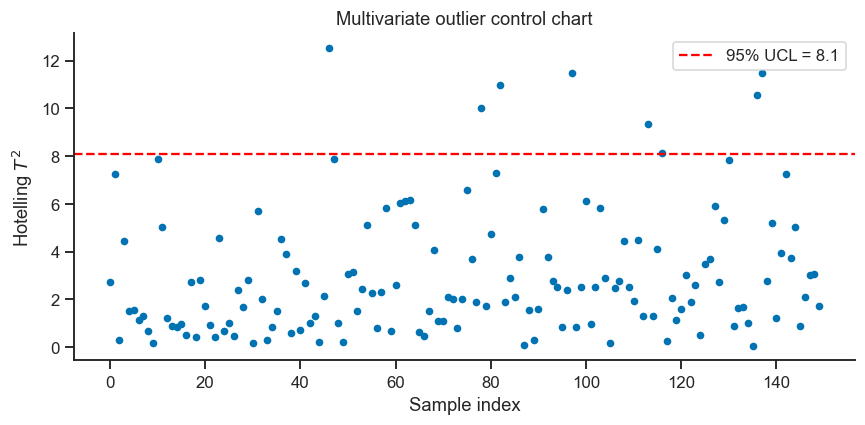

8 sample(s) flagged as multivariate outliers: ['NMC-047', 'NMC-079', 'NMC-083', 'NMC-098', 'NMC-114', 'NMC-117', 'NMC-137', 'NMC-138']


In [9]:
from scipy.stats import f as f_dist

n_components_T2 = 3
scores_T2 = scores_sklearn[:, :n_components_T2]
eigenvalues_T2 = pca_sklearn.explained_variance_[:n_components_T2]

# T^2 for each sample: sum of (score_i / sqrt(eigenvalue_i))^2 across components
T2 = np.sum((scores_T2 / np.sqrt(eigenvalues_T2))**2, axis=1)

# 95% control limit via the F-distribution (standard Hotelling T^2 formula)
alpha = 0.05
UCL = (n_components_T2 * (n - 1) / (n - n_components_T2)) * \
      f_dist.ppf(1 - alpha, n_components_T2, n - n_components_T2)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(n), T2, 'o', ms=4, color=sns.color_palette('colorblind')[0])
ax.axhline(UCL, color='red', ls='--', label=f'95% UCL = {UCL:.1f}')
ax.set_xlabel('Sample index'); ax.set_ylabel('Hotelling $T^2$')
ax.set_title('Multivariate outlier control chart')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

flagged = df_cathode.loc[T2 > UCL, 'sample_id'].tolist()
print(f'{len(flagged)} sample(s) flagged as multivariate outliers: {flagged}')

:::{admonition} Take-home message
:class: tip

- 8 of 150 samples (5.3%) were flagged — remarkably close to the 5% the 95% control limit is *calibrated* to flag by pure chance alone, even with no genuine process problem. That is itself a useful sanity check: if 25 samples had been flagged instead of 8, that would be a signal something systematic is wrong (a drifting instrument, a mislabelled batch), not just normal statistical variation.
- Being flagged does not automatically mean "bad sample" — it means "jointly unusual across the retained components," which is worth a second look (Section 16.1's Ni-content trade-off is one plausible, entirely legitimate reason a real sample could sit far from the bulk) rather than an automatic reason to discard the data point.
:::

## 16.5 From PCA to Factor Analysis: What Changes, and Why

PCA and Factor Analysis look similar — both start from a correlation
matrix, both produce a small number of "components" — but they answer
different questions:

| | PCA | Factor Analysis |
|---|---|---|
| Goal | **Compress** variance — find axes that reconstruct the data as well as possible | **Explain** correlation — find hidden causes producing the *shared* variance |
| Uses | *Total* variance (diagonal = 1) | Only *common* variance (diagonal = communalities, < 1) |
| Model | $X = TP^\top$ (exact, no error term) | $X = \Lambda F + \varepsilon$ (explicit unique/error term per variable) |
| "Leftover" variance | Distributed across all components | Isolated as each variable's own **uniqueness** |

That last row is the practical difference: FA explicitly separates
*"variance this variable shares with others"* from *"variance unique to
this one measurement (including noise)."* This dataset was literally
**built** using the FA equation from Section 16.3's generation code
(`unique_var = 1 - sum of squared loadings`) — so FA should recover the
true 3-factor structure cleanly, which makes it a good dataset for seeing
FA work as intended before you apply it to messier, real data.

Two checks confirm correlated structure exists worth factoring at all
(skip FA if either fails):

In [10]:
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

chi_sq, p_bartlett = calculate_bartlett_sphericity(df_cathode[feature_cols])
print(f"Bartlett's test of sphericity: chi2={chi_sq:.1f}, p={p_bartlett:.2e}")
print('(p << 0.05 means the variables are NOT an uncorrelated identity matrix -- good, FA is worth doing)')

kmo_per_var, kmo_overall = calculate_kmo(df_cathode[feature_cols])
print(f'\nKMO measure of sampling adequacy: {kmo_overall:.2f}')
print('(> 0.6 is usually considered acceptable for FA; > 0.8 is very good)')

Bartlett's test of sphericity: chi2=516.7, p=2.14e-81
(p << 0.05 means the variables are NOT an uncorrelated identity matrix -- good, FA is worth doing)

KMO measure of sampling adequacy: 0.69
(> 0.6 is usually considered acceptable for FA; > 0.8 is very good)


## 16.6 How Many Factors? Parallel Analysis

The scree plot in Section 16.3 suggested 3 components by eyeballing where
the curve "elbows" — a genuinely subjective call. **Parallel analysis** is
a sharper, near-automatic answer: simulate many datasets of *pure random
noise* with the same shape as yours, compute their eigenvalues, and keep
only the real components whose eigenvalue exceeds what pure noise
typically produces. Anything below that line is indistinguishable from
noise.

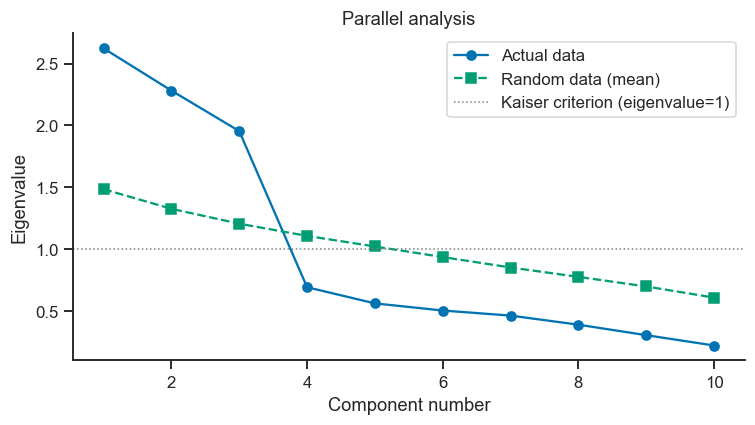

Parallel analysis suggests retaining 3 factors.
Kaiser criterion (eigenvalue > 1) suggests retaining 3 factors.


In [11]:
def parallel_analysis(X, n_iter=200, seed=0):
    """Return the real eigenvalues and the mean eigenvalues of n_iter
    randomly shuffled (noise) datasets of the same shape."""
    pa_rng = np.random.default_rng(seed)
    n_obs, n_vars = X.shape
    X_std = (X - X.mean(axis=0)) / X.std(axis=0, ddof=1)
    real_eigs = np.linalg.eigvalsh(np.cov(X_std, rowvar=False))[::-1]

    random_eigs = np.zeros((n_iter, n_vars))
    for i in range(n_iter):
        X_random = pa_rng.normal(size=(n_obs, n_vars))
        random_eigs[i] = np.linalg.eigvalsh(np.cov(X_random, rowvar=False))[::-1]

    return real_eigs, random_eigs.mean(axis=0)


real_eigs, random_eigs = parallel_analysis(X)
n_suggested = int(np.sum(real_eigs > random_eigs))

fig, ax = plt.subplots(figsize=(7, 4))
comp_idx = range(1, len(feature_cols)+1)
ax.plot(comp_idx, real_eigs, 'o-', label='Actual data', color=sns.color_palette('colorblind')[0])
ax.plot(comp_idx, random_eigs, 's--', label='Random data (mean)', color=sns.color_palette('colorblind')[2])
ax.axhline(1.0, color='gray', ls=':', lw=1, label='Kaiser criterion (eigenvalue=1)')
ax.set_xlabel('Component number'); ax.set_ylabel('Eigenvalue')
ax.set_title('Parallel analysis')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

print(f'Parallel analysis suggests retaining {n_suggested} factors.')
print(f'Kaiser criterion (eigenvalue > 1) suggests retaining {int(np.sum(real_eigs > 1))} factors.')

## 16.7 Fitting and Rotating the Factor Model

With the number of factors decided, fit FA and apply **varimax
rotation** — a transformation that keeps the model's overall fit identical
but rotates the factor axes to make each one load strongly on as *few*
variables as possible, which is almost always easier to interpret than
the raw (unrotated) solution.

In [12]:
from factor_analyzer import FactorAnalyzer

n_factors = 3
fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax', method='principal')
fa.fit(df_cathode[feature_cols])

fa_loadings = pd.DataFrame(fa.loadings_, index=feature_cols,
                            columns=[f'Factor{i+1}' for i in range(n_factors)])
print(fa_loadings.round(2))

communalities = pd.Series(fa.get_communalities(), index=feature_cols, name='communality')
print('\nCommunalities (share of each variable\'s variance explained by the common factors):')
print(communalities.round(2))

                               Factor1  Factor2  Factor3
particle_size_D50_um             -0.05     0.03     0.85
BET_surface_area_m2g             -0.01     0.03    -0.88
tap_density_gcm3                 -0.05     0.06     0.71
first_cycle_capacity_mAhg         0.88     0.00     0.06
coulombic_efficiency_pct          0.73    -0.29    -0.08
rate_capability_pct               0.73    -0.10    -0.28
Ni_content_pct                    0.78     0.35     0.19
capacity_retention_100cyc_pct     0.08    -0.87    -0.04
impedance_growth_pct             -0.08     0.81     0.08
lattice_strain_pct                0.06     0.78    -0.05

Communalities (share of each variable's variance explained by the common factors):
particle_size_D50_um             0.72
BET_surface_area_m2g             0.78
tap_density_gcm3                 0.50
first_cycle_capacity_mAhg        0.78
coulombic_efficiency_pct         0.63
rate_capability_pct              0.63
Ni_content_pct                   0.77
capacity_retention_100c

**Checkpoint / Exercise B**: Match each rotated factor to one of Section
16.1's three physical concepts (Morphology / Performance / Stability) by
reading off which variables load strongly (|loading| > 0.5, say) on each
column. Which variable has the lowest communality, and what does a low
communality mean about how well the common factors explain that
particular measurement?

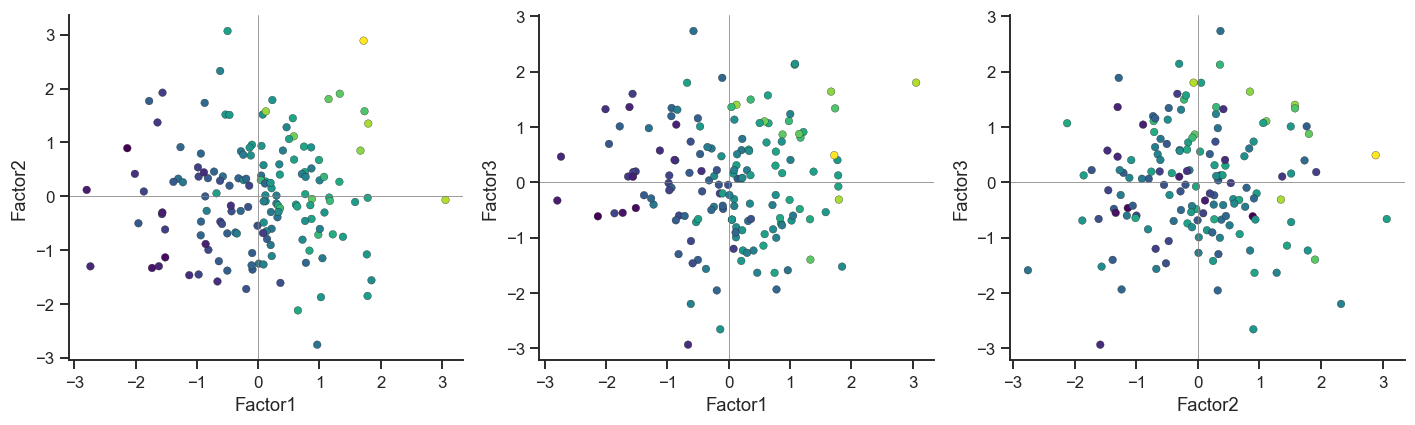

In [13]:
factor_scores = fa.transform(df_cathode[feature_cols])
df_fa_scores = pd.DataFrame(factor_scores, columns=[f'Factor{i+1}' for i in range(n_factors)])

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
pairs = [(0, 1), (0, 2), (1, 2)]
for ax, (i, j) in zip(axes, pairs):
    sc = ax.scatter(df_fa_scores[f'Factor{i+1}'], df_fa_scores[f'Factor{j+1}'],
                     c=df_cathode['Ni_content_pct'], cmap='viridis', s=25, edgecolor='k', linewidth=0.2)
    ax.set_xlabel(f'Factor{i+1}'); ax.set_ylabel(f'Factor{j+1}')
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
sns.despine()
plt.tight_layout()
plt.show()

## 16.8 PCA vs. FA, Side by Side

Same data, two methods, two different sets of loadings. Comparing them
directly makes theory.md's PCA-vs-FA table concrete rather than abstract.

In [14]:
comparison = pd.DataFrame({
    'PCA_PC1': loadings_df['PC1'],
    'FA_Factor (best match)': fa_loadings.abs().idxmax(axis=1),
    'FA_loading (best match)': fa_loadings.abs().max(axis=1) * np.sign(
        fa_loadings.values[np.arange(len(feature_cols)), fa_loadings.abs().values.argmax(axis=1)]),
})
print(comparison.round(2))
print('\nNotice PCA\'s first component mixes information from more variables at once')
print('(it is chasing total variance), while each FA factor concentrates loading onto a')
print('smaller, more physically coherent subset (it is chasing shared/common variance only).')

                               PCA_PC1 FA_Factor (best match)  \
particle_size_D50_um             -0.26                Factor3   
BET_surface_area_m2g              0.22                Factor3   
tap_density_gcm3                 -0.23                Factor3   
first_cycle_capacity_mAhg         0.40                Factor1   
coulombic_efficiency_pct          0.45                Factor1   
rate_capability_pct               0.45                Factor1   
Ni_content_pct                    0.22                Factor1   
capacity_retention_100cyc_pct     0.30                Factor2   
impedance_growth_pct             -0.30                Factor2   
lattice_strain_pct               -0.19                Factor2   

                               FA_loading (best match)  
particle_size_D50_um                              0.85  
BET_surface_area_m2g                             -0.88  
tap_density_gcm3                                  0.71  
first_cycle_capacity_mAhg                         0.88  

## 16.9 Going Further: Factor Scores as Compressed Predictors

One more question: can 3 factor scores predict something they were never
even shown? Add a variable the factor model never saw —
**manufacturing cost** — built here from `Ni_content_pct` alone (in real
NMC production, higher nickel content generally *lowers* cost, since it
displaces the far more expensive cobalt) plus noise, and see how well the
compressed factor scores explain it compared to the raw 10 variables.

In [15]:
cost_usd_per_kwh = (140 - 0.55 * df_cathode['Ni_content_pct'] + rng.normal(0, 4, n))

import statsmodels.api as sm

# Model 1: predict cost from the 3 factor scores only
X_factors = sm.add_constant(df_fa_scores)
model_factors = sm.OLS(cost_usd_per_kwh, X_factors).fit()

# Model 2: predict cost from all 10 raw variables (much higher-dimensional)
X_raw = sm.add_constant(df_cathode[feature_cols])
model_raw = sm.OLS(cost_usd_per_kwh, X_raw).fit()

print(f'R² using 3 factor scores:  {model_factors.rsquared:.3f}  (3 predictors)')
print(f'R² using all 10 raw vars:  {model_raw.rsquared:.3f}  (10 predictors)')
print('\nThree compressed factor scores recover a large share of the full model\'s')
print('predictive power from just 3 predictors instead of 10 -- the practical payoff of')
print('dimensionality reduction: fewer, more interpretable predictors for a modest, and')
print('here quantified, loss of fit (Notebook 7, Live Tutorial 2 next session formalises')
print('this trade-off properly as PLS/PCR, which choose components to predict Y directly')
print('rather than just to summarise X).')

R² using 3 factor scores:  0.540  (3 predictors)
R² using all 10 raw vars:  0.748  (10 predictors)

Three compressed factor scores recover a large share of the full model's
predictive power from just 3 predictors instead of 10 -- the practical payoff of
dimensionality reduction: fewer, more interpretable predictors for a modest, and
here quantified, loss of fit (Notebook 7, Live Tutorial 2 next session formalises
this trade-off properly as PLS/PCR, which choose components to predict Y directly
rather than just to summarise X).


---
## Exercises

**Core practice**

1. **Manual reconstruction**: Using `scores_manual` and `loadings_manual`
   from Section 16.2, reconstruct an approximation of the standardized data
   using only the first 3 components:
   `X_approx = scores_manual[:, :3] @ loadings_manual[:, :3].T`. Compute the
   root-mean-square reconstruction error against the true standardized `X`,
   and compare it to the same calculation using all 10 components (which
   should reconstruct exactly, error ≈ 0).

2. **Unscaled PCA**: Refit `sklearn.decomposition.PCA` on the *raw* (not
   standardized) `X`. Which variable dominates PC1 now, and why (hint:
   compare the raw units and typical magnitudes of `first_cycle_capacity_mAhg`
   vs. `lattice_strain_pct`)? This is the same lesson Notebook 12, Exercise
   2 teaches — standardization is not optional when variables are on
   different scales.

3. **3D interactive score plot**: Using `plotly.express.scatter_3d`
   (Part I, Notebook 5), plot PC1/PC2/PC3 scores coloured by
   `capacity_retention_100cyc_pct` and rotate it interactively. Does a
   3rd axis reveal separation that the 2-D PC1-PC2 plot in Section 16.3
   hid?

**Deeper practice**

4. **Promax (oblique) rotation**: Refit the factor model with
   `rotation='promax'` instead of `'varimax'`. Varimax forces factors to
   stay uncorrelated with each other; promax allows correlated factors —
   which is arguably more realistic here, since "Performance" and
   "Stability" are physically linked by the Ni-content trade-off. Compare
   the loadings and, if you're using `factor_analyzer`'s `phi_` attribute,
   inspect the factor correlation matrix it reports.

5. **4-factor solution**: Deliberately over-extract with `n_factors=4` and
   refit. Look at the communalities and the 4th factor's loadings — does
   it correspond to any real physical concept, or does it look like it's
   fitting noise? This is the practical failure mode parallel analysis
   (Section 16.6) exists to prevent.

6. **Break the Ni trade-off**: Go back to Section 16.1's `loadings_true` and
   change `Ni_content_pct`'s stability loading from `-0.40` to `0.00`
   (removing the trade-off entirely), regenerate the dataset, and redo
   Sections 16.3 and 16.7. How does the PCA loading plot's geometry change
   for `Ni_content_pct` relative to the stability-related variables?

7. **Your own latent-variable dataset**: Design a new synthetic dataset (a
   different materials system — polymers, ceramics, alloys) built from 2–4
   named hidden factors, following Section 16.1's generative recipe. Run
   the full PCA + parallel analysis + FA workflow on it and confirm the
   number of factors recovered matches what you built in.